# Homework 2
## Анализ текста, текстовые модели


### Часть 2: Классификация тональности с помощью BERT

Задача:

Цель этой задачи — использовать предварительно обученную модель BERT для классификации тональности рецензий на фильмы.

[IMDB Dataset](https://disk.yandex.ru/d/dhKpEgM4rQkLiQ)

#### **Задание для части 2:**

Используйте предварительно обученную модель BERT для классификации тональности отзывов о фильмах. (Вес задания: 20%)

In [4]:
#!pip install pandas numpy torch torchaudio torchvision transformers tqdm scikit-learn gdown

In [5]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import BertModel, BertPreTrainedModel, BertConfig
from transformers import BertForSequenceClassification, BertTokenizerFast

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import matplotlib.pyplot as plt

from tqdm import tqdm

import warnings
import gdown
import os
import re

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"current device: {device}")


current device: cuda


In [6]:
# download csv if there is not;

if not os.path.exists('IMDB.csv'):
    url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vT6-n57dcXO2nHTwmAkZSw_MGYGSd5vFIE0TtrnmePnzM37Jev_0mpXdVbLZqVLcnAYkyBpkztKpQH2/pub?output=csv'
    gdown.download(url, 'IMDB.csv', quiet=False)


Downloading...
From: https://docs.google.com/spreadsheets/d/e/2PACX-1vT6-n57dcXO2nHTwmAkZSw_MGYGSd5vFIE0TtrnmePnzM37Jev_0mpXdVbLZqVLcnAYkyBpkztKpQH2/pub?output=csv
To: /content/IMDB.csv
66.3MB [00:06, 10.0MB/s]


In [7]:
def clean(text):
    if not isinstance(text, str):
        return ""
    # html-tags
    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)

    # words with dots
    text = re.sub(r'\.([A-Za-z])', r'. \1', text)
    text = re.sub(r'\!([A-Za-z])', r'! \1', text)
    text = re.sub(r'\?([A-Za-z])', r'? \1', text)

    # many spaces
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # unicode anomaly
    text = re.sub(r'[^\w\s\.\!\?\:\;\,\'\"\(\)\-\–\—]', ' ', text, flags=re.UNICODE)

    return text


In [8]:
# loading data; splitting

imdb_raw = pd.read_csv('IMDB.csv')
texts = imdb_raw['review'].apply(clean)
clean_texts = texts.values
labels = imdb_raw['sentiment'].map({'negative': 0, 'positive': 1}).values


 АНАЛИЗ ДЛИНЫ ТЕКСТОВ 


Анализ на полном датасете (50000 записей)

1. СИМВОЛЫ:
   Среднее: 1309
   Медиана: 970
   Максимум: 13704
   95-й перцентиль: 3391
   99-й перцентиль: 5179

2. ТОКЕНИЗАЦИЯ BERT (bert-base-uncased):


Токенизация: 100%|██████████| 50000/50000 [00:51<00:00, 979.48it/s] 



   Статистика по токенам (WordPiece):
   Среднее: 310
   Медиана: 231
   Максимум: 3157
   95-й перцентиль: 796
   99-й перцентиль: 1198

3. АНАЛИЗ ОБРЕЗКИ (BERT лимит = 512 токенов):
Длиннее 512 токенов: 7214 (14.4%) - БУДУТ ОБРЕЗАНЫ
Длиннее 384 токенов: 12131 (24.3%) - риск потери данных
Короче 256 токенов: 28100 (56.2%) - идеально

4. РАСПРЕДЕЛЕНИЕ ПО КВАРТИЛЯМ:
       0-й перцентиль:      5 токенов
      25-й перцентиль:    167 токенов
      50-й перцентиль:    231 токенов
      75-й перцентиль:    377 токенов
      90-й перцентиль:    609 токенов
      95-й перцентиль:    796 токенов
      99-й перцентиль:   1198 токенов
     100-й перцентиль:   3157 токенов


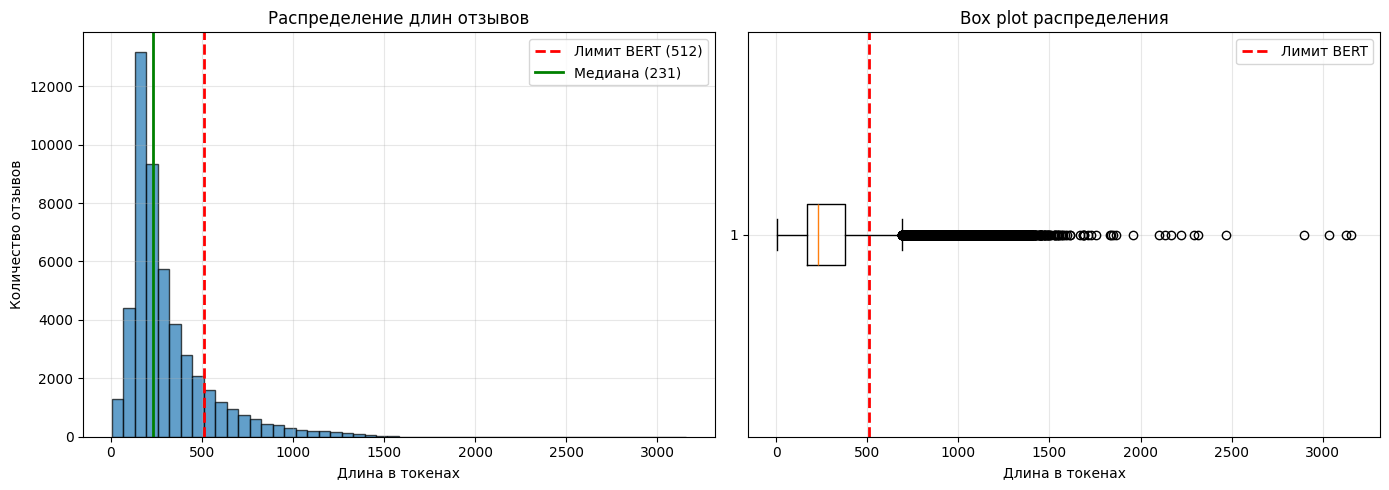

Более 5% отзывов длиннее 512 токенов!


In [20]:
def analyze_text_lengths(df, text_column='clean_review', sample_size=None):

    print(" АНАЛИЗ ДЛИНЫ ТЕКСТОВ " + "\n" + "="*60 + '\n')


    if sample_size and len(df) > sample_size:
        df_sample = df.sample(n=sample_size, random_state=42)
        print(f"\nАнализ на выборке {sample_size} из {len(df)} записей")
    else:
        df_sample = df
        print(f"\nАнализ на полном датасете ({len(df)} записей)")

    df_sample['char_len'] = df_sample[text_column].astype(str).str.len()

    print("\n1. СИМВОЛЫ:")
    print(f"   Среднее: {df_sample['char_len'].mean():.0f}")
    print(f"   Медиана: {df_sample['char_len'].median():.0f}")
    print(f"   Максимум: {df_sample['char_len'].max()}")
    print(f"   95-й перцентиль: {df_sample['char_len'].quantile(0.95):.0f}")
    print(f"   99-й перцентиль: {df_sample['char_len'].quantile(0.99):.0f}")

    print("\n2. ТОКЕНИЗАЦИЯ BERT (bert-base-uncased):")

    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

    def count_tokens(text):
        return len(tokenizer.encode(text, truncation=False))

    from tqdm import tqdm
    tqdm.pandas(desc="Токенизация")
    df_sample['token_len'] = df_sample[text_column].progress_apply(count_tokens)

    print(f"\n   Статистика по токенам (WordPiece):")
    print(f"   Среднее: {df_sample['token_len'].mean():.0f}")
    print(f"   Медиана: {df_sample['token_len'].median():.0f}")
    print(f"   Максимум: {df_sample['token_len'].max()}")
    print(f"   95-й перцентиль: {df_sample['token_len'].quantile(0.95):.0f}")
    print(f"   99-й перцентиль: {df_sample['token_len'].quantile(0.99):.0f}")

    print("\n3. АНАЛИЗ ОБРЕЗКИ (BERT лимит = 512 токенов):")

    total_samples = len(df_sample)
    exceeding_512 = (df_sample['token_len'] > 512).sum()
    exceeding_384 = (df_sample['token_len'] > 384).sum()
    exceeding_256 = (df_sample['token_len'] > 256).sum()

    print(f"Длиннее 512 токенов: {exceeding_512} ({exceeding_512/total_samples*100:.1f}%) - БУДУТ ОБРЕЗАНЫ")
    print(f"Длиннее 384 токенов: {exceeding_384} ({exceeding_384/total_samples*100:.1f}%) - риск потери данных")
    print(f"Короче 256 токенов: {total_samples - exceeding_256} ({(total_samples - exceeding_256)/total_samples*100:.1f}%) - идеально")

    print("\n4. РАСПРЕДЕЛЕНИЕ ПО КВАРТИЛЯМ:")
    percentiles = [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
    for p in percentiles:
        val = df_sample['token_len'].quantile(p)
        print(f"   {p*100:5.0f}-й перцентиль: {val:6.0f} токенов")



    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df_sample['token_len'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=512, color='red', linestyle='--', linewidth=2, label='Лимит BERT (512)')
    axes[0].axvline(x=df_sample['token_len'].median(), color='green', linestyle='-', linewidth=2, label=f'Медиана ({df_sample["token_len"].median():.0f})')
    axes[0].set_xlabel('Длина в токенах')
    axes[0].set_ylabel('Количество отзывов')
    axes[0].set_title('Распределение длин отзывов')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].boxplot(df_sample['token_len'], vert=False)
    axes[1].axvline(x=512, color='red', linestyle='--', linewidth=2, label='Лимит BERT')
    axes[1].set_xlabel('Длина в токенах')
    axes[1].set_title('Box plot распределения')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    if exceeding_512 / total_samples < 0.01:
        print("Меньше 1% отзывов длиннее 512 токенов.")
    elif exceeding_512 / total_samples < 0.05:
        print("1-5% отзывов будут обрезаны.")
    else:
        print("Более 5% отзывов длиннее 512 токенов!")

    return df_sample[['char_len', 'token_len']]


results = analyze_text_lengths(imdb_raw, text_column='review')

In [10]:
class IMDBDataset(Dataset):
    def __init__(self, input_ids_list, attention_masks_list, labels):
        self.input_ids = [torch.tensor(ids, dtype=torch.long) for ids in input_ids_list]
        self.attention_masks = [torch.tensor(mask, dtype=torch.long) for mask in attention_masks_list]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'label': self.labels[idx]
        }


In [11]:
def pre_tokenize_imdb(texts, tokenizer, max_len=512, head_len=128, tail_len=384):
    """
    Токенизирует все тексты один раз и возвращает списки input_ids и attention_masks
    """
    if head_len is None and tail_len is None:
        head_len = int((max_len - 2) * 0.3)
        tail_len = (max_len - 2) - head_len

    input_ids_list = []
    attention_masks_list = []

    for text in tqdm(texts, desc="Токенизация"):
        encoding = tokenizer(
            text,
            truncation=False,
            padding=False,
            return_tensors=None
        )

        input_ids = encoding['input_ids']

        if len(input_ids) > max_len:
            cls_token = [input_ids[0]]
            sep_token = [input_ids[-1]]
            body = input_ids[1:-1]

            if len(body) > head_len + tail_len:
                new_body = body[:head_len] + body[-tail_len:]
            else:
                new_body = body

            input_ids = cls_token + new_body + sep_token
            attention_mask = [1] * len(input_ids)
        else:
            attention_mask = encoding['attention_mask']

        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)

    return input_ids_list, attention_masks_list


In [12]:
def collate_fn(batch):
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])

    max_len = max(ids.size(0) for ids in input_ids)

    padded_ids = torch.zeros(len(batch), max_len, dtype=torch.long)
    padded_masks = torch.zeros(len(batch), max_len, dtype=torch.long)

    for i, ids in enumerate(input_ids):
        length = ids.size(0)
        padded_ids[i, :length] = ids
        padded_masks[i, :length] = attention_masks[i]

    return {
        'input_ids': padded_ids,
        'attention_mask': padded_masks,
        'labels': labels
    }


In [13]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

train_texts, test_texts, train_labels, test_labels = train_test_split(
			clean_texts,
			labels,
			test_size=0.2,
			random_state=666,
			stratify=labels
			)

train_texts = train_texts.tolist()
test_texts = test_texts.tolist()


train_input_ids, train_attention_masks = pre_tokenize_imdb(
    train_texts,
    tokenizer,
    max_len=512,
    head_len=127,
    tail_len=383
)

test_input_ids, test_attention_masks = pre_tokenize_imdb(
    test_texts,
    tokenizer,
    max_len=512,
    head_len=127,
    tail_len=38
)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Токенизация: 100%|██████████| 10000/10000 [00:11<00:00, 898.31it/s]


In [14]:
train_dataset = IMDBDataset(train_input_ids, train_attention_masks, train_labels)
test_dataset = IMDBDataset(test_input_ids, test_attention_masks, test_labels)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"{len(train_dataset)} train, {len(test_dataset)} test")

40000 train, 10000 test


In [15]:
class IMDBert(nn.Module):
    def __init__(self, n_classes=2, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = outputs.last_hidden_state[:, 0, :]

        x = self.dropout(pooled_output)
        logits = self.classifier(x)

        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = IMDBert(n_classes=2).to(device)

print(f"Модель создана. Параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"Устройство: {device}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель создана. Параметров: 109,483,778
Устройство: cuda


In [ ]:
from transformers import get_linear_schedule_with_warmup


total_steps = len(train_loader) * 3

optimizer = AdamW(model.parameters(), lr=2e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

scaler = GradScaler()


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc=f'Эпоха {epoch+1} [Train]')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast():
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        avg_loss = total_loss / total
        avg_acc = correct / total

        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',      # loss на текущем батче
            'avg_loss': f'{avg_loss:.4f}',     # средний loss за эпоху
            'acc': f'{avg_acc:.4f}'            # средняя accuracy за эпоху
        })

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device, epoch):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc=f'Эпоха {epoch+1} [Test]')

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            avg_loss = total_loss / total
            avg_acc = correct / total

            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{avg_loss:.4f}',
                'acc': f'{avg_acc:.4f}'
            })

    return total_loss / len(loader), correct / total




In [18]:
print(f"Устройство: {device}")
print(f"Train батчей: {len(train_loader)}, Test батчей: {len(test_loader)}")
print("=" * 50)

for epoch in range(3):
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, epoch
    )
    test_loss, test_acc = eval_epoch(
        model, test_loader, criterion, device, epoch
    )

    print("\n" + "=" * 50)
    print(f"epoch {epoch+1} done")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("=" * 50 + "\n")


print('Done!')
print(f"accuracy: {test_acc:.4f}")


Устройство: cuda
Train батчей: 2500, Test батчей: 625


Эпоха 1 [Test]: 100%|██████████| 625/625 [04:38<00:00,  2.24it/s, loss=0.0274, avg_loss=0.0147, acc=0.9275]



epoch 1 done
  Train Loss: 0.2556 | Train Acc: 0.8939
  Test Loss:  0.2359 | Test Acc:  0.9275



Эпоха 2 [Test]: 100%|██████████| 625/625 [04:40<00:00,  2.23it/s, loss=0.0284, avg_loss=0.0144, acc=0.9399]



epoch 2 done
  Train Loss: 0.1294 | Train Acc: 0.9624
  Test Loss:  0.2300 | Test Acc:  0.9399



Эпоха 3 [Test]: 100%|██████████| 625/625 [04:39<00:00,  2.24it/s, loss=0.2204, avg_loss=0.0178, acc=0.9402]


epoch 3 done
  Train Loss: 0.0604 | Train Acc: 0.9855
  Test Loss:  0.2853 | Test Acc:  0.9402

Done!
accuracy: 0.9402


In [19]:
torch.save(model.state_dict(), 'bert_imdb_final.pt')


In [21]:
torch.save(model, 'bert_full_imdb.pt')
